In [1]:
'''
Model Training
date: 2026-03-03
target: 训练模型，用户复购预测

训练两个模型：
1. 平销期模型:用1-3月预测4/5月
2. 促销期模型:用1-5月预测6月(618)

模型选择:XGBoost + LightGBM
评估指标:AUC, Precision, Recall, F1
'''

'\nModel Training\ndate: 2026-03-03\ntarget: 训练模型，用户复购预测\n\n训练两个模型：\n1. 平销期模型:用1-3月预测4/5月\n2. 促销期模型:用1-5月预测6月(618)\n\n模型选择:XGBoost + LightGBM\n评估指标:AUC, Precision, Recall, F1\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_curve
)
import xgboost as xgb
import lightgbm as lgb
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 加载4月、5月、6月的特征数据
data_month4 = pd.read_csv('../data/features/user_features_month4.csv')
data_month5 = pd.read_csv('../data/features/user_features_month5.csv')
data_month6 = pd.read_csv('../data/features/user_features_month6.csv')

print(f"4月数据: {data_month4.shape}")
print(f"5月数据: {data_month5.shape}")
print(f"6月数据: {data_month6.shape}")

# 特征列（排除user_id和label）
feature_cols = [col for col in data_month4.columns 
                if col not in ['user_id', 'label']]

print(f"\n特征数: {len(feature_cols)}")

4月数据: (544307, 73)
5月数据: (544307, 73)
6月数据: (544307, 73)

特征数: 71


## 数据集划分策略

模型1：平销期模型
- 训练集：4月数据（用1-3月特征预测4月）
- 验证集：从4月数据中分出20%
- 测试集：5月数据（用1-3月特征预测5月）

模型2：促销期模型（618）
- 训练集：4月+5月数据
- 验证集：从训练集中分出20%
- 测试集：6月数据（618大促）

#### 模型1：平销期模型

In [4]:
# 4月数据作为训练+验证
X_train_val = data_month4[feature_cols]
y_train_val = data_month4['label']

# 分割训练集和验证集（70:30）
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.3, 
    random_state=42,
    stratify=y_train_val  # 保持正负样本比例
)

# 5月数据作为测试集
X_test = data_month5[feature_cols]
y_test = data_month5['label']

print(f"训练集: {X_train.shape}, 正样本率: {y_train.mean()*100:.2f}%")
print(f"验证集: {X_val.shape}, 正样本率: {y_val.mean()*100:.2f}%")
print(f"测试集: {X_test.shape}, 正样本率: {y_test.mean()*100:.2f}%")

训练集: (381014, 71), 正样本率: 48.00%
验证集: (163293, 71), 正样本率: 48.00%
测试集: (544307, 71), 正样本率: 47.40%


##### 训练XGBoost模型

训练XGBoost模型...

XGBoost 模型性能:
训练集 AUC: 0.7048
验证集 AUC: 0.7010
测试集 AUC: 0.6677


<Figure size 1000x600 with 0 Axes>

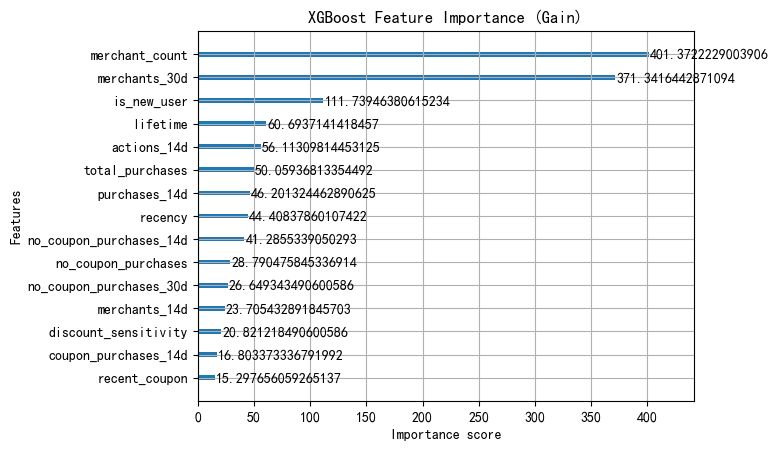

In [5]:
# XGBoost参数
xgb_params = {
    'max_depth': 6,
    'learning_rate': 0.05,             # 降低学习率，提升模型稳定性
    'n_estimators': 500,               # 增大树的数量，配合早停
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
    'early_stopping_rounds': 20,       # 增加早停耐心值
    'colsample_bytree': 0.8,           # 每棵树随机采样的特征比例，防止过拟合
    'subsample': 0.8                   # 训练每棵树使用的样本比例
}

# 训练模型
print("训练XGBoost模型...")
xgb_model = xgb.XGBClassifier(**xgb_params)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# 预测概率 (用于 AUC 和 后续融合)
y_prob_train = xgb_model.predict_proba(X_train)[:, 1]
y_prob_val = xgb_model.predict_proba(X_val)[:, 1]
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

# 预测类别 (默认阈值 0.5)
y_pred_test = xgb_model.predict(X_test)

# 评估
print(f"\nXGBoost 模型性能:")
print(f"训练集 AUC: {roc_auc_score(y_train, y_prob_train):.4f}")
print(f"验证集 AUC: {roc_auc_score(y_val, y_prob_val):.4f}")
print(f"测试集 AUC: {roc_auc_score(y_test, y_prob_test):.4f}")

# 特征重要性分析
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=15, importance_type='gain')
plt.title('XGBoost Feature Importance (Gain)')
plt.show()

##### 训练LightGBM模型

训练LightGBM模型...
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[134]	valid_0's auc: 0.700921

LightGBM 模型性能:
训练集 AUC: 0.7022
验证集 AUC: 0.7009
测试集 AUC: 0.6674


<Figure size 1000x600 with 0 Axes>

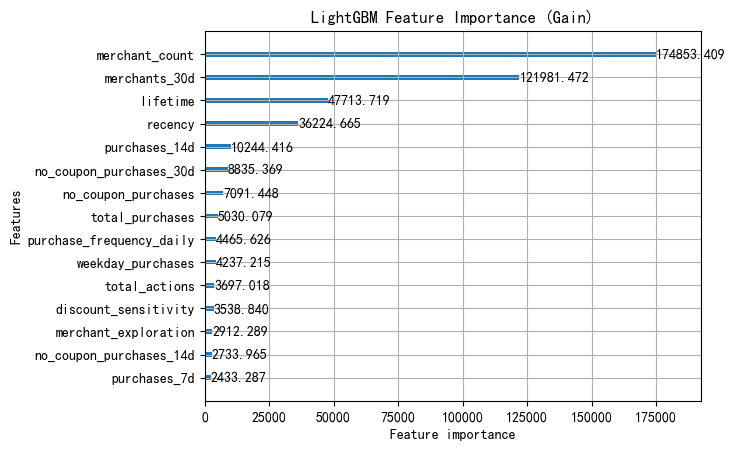

In [6]:
# LightGBM参数 (稍微调整以提升鲁棒性)
lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'n_estimators': 500,               # 增大迭代次数，依靠早停控制
    'learning_rate': 0.05,             # 降低学习率
    'max_depth': 6,
    'num_leaves': 31,                  # 限制叶子数防止过拟合
    'feature_fraction': 0.8,           # 特征采样
    'bagging_fraction': 0.8,           # 数据采样
    'bagging_freq': 5,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

# 训练模型
print("训练LightGBM模型...")
lgb_model = lgb.LGBMClassifier(**lgb_params)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20),
        lgb.log_evaluation(period=0)
    ]
)

# 预测概率
y_prob_train_lgb = lgb_model.predict_proba(X_train)[:, 1]
y_prob_val_lgb = lgb_model.predict_proba(X_val)[:, 1]
y_prob_test_lgb = lgb_model.predict_proba(X_test)[:, 1]

# 预测类别 (默认阈值 0.5)
y_pred_test_lgb = lgb_model.predict(X_test)

# 评估
print(f"\nLightGBM 模型性能:")
print(f"训练集 AUC: {roc_auc_score(y_train, y_prob_train_lgb):.4f}")
print(f"验证集 AUC: {roc_auc_score(y_val, y_prob_val_lgb):.4f}")
print(f"测试集 AUC: {roc_auc_score(y_test, y_prob_test_lgb):.4f}")

# 特征重要性分析
plt.figure(figsize=(10, 6))
lgb.plot_importance(lgb_model, max_num_features=15, importance_type='gain')
plt.title('LightGBM Feature Importance (Gain)')
plt.show()

##### 模型融合

In [7]:
# 1. 投票融合 (Soft Voting / 加权概率平均)
# 使用预测出的 概率 而不是类别进行融合，通常会有更好的效果。

# 加权平均测试集的概率 (XGB 0.4 + LGB 0.6，通常 LGB 更稳)
y_prob_ensemble = (y_prob_test * 0.4) + (y_prob_test_lgb * 0.6)

# 评估融合模型 AUC
ensemble_auc = roc_auc_score(y_test, y_prob_ensemble)
print(f"融合模型 (加权概率叠加) AUC: {ensemble_auc:.4f}")

# 2. 阈值寻优：选择使 F1 最大化的最优阈值
thresholds = np.arange(0.1, 0.8, 0.01)
best_threshold = 0.5
best_f1 = 0

for threshold in thresholds:
    y_pred_binary = (y_prob_ensemble >= threshold).astype(int)
    # 增加一个小微量的 zero_division 处理，防止极端情况报错
    f1 = f1_score(y_test, y_pred_binary, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n最优阈值寻优完成:")
print(f"- 最优阈值: {best_threshold:.2f}")
print(f"- 最高 F1 得分: {best_f1:.4f}")

# 3. 使用最优阈值进行最终决策
y_pred_final = (y_prob_ensemble >= best_threshold).astype(int)

# 详细评估
print(f"\n融合模型详细指标 (测试集):")
print(f"  Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_final):.4f}")

融合模型 (加权概率叠加) AUC: 0.6676

最优阈值寻优完成:
- 最优阈值: 0.30
- 最高 F1 得分: 0.6456

融合模型详细指标 (测试集):
  Precision: 0.4988
  Recall:    0.9147
  F1-Score:  0.6456


##### 可视化评估

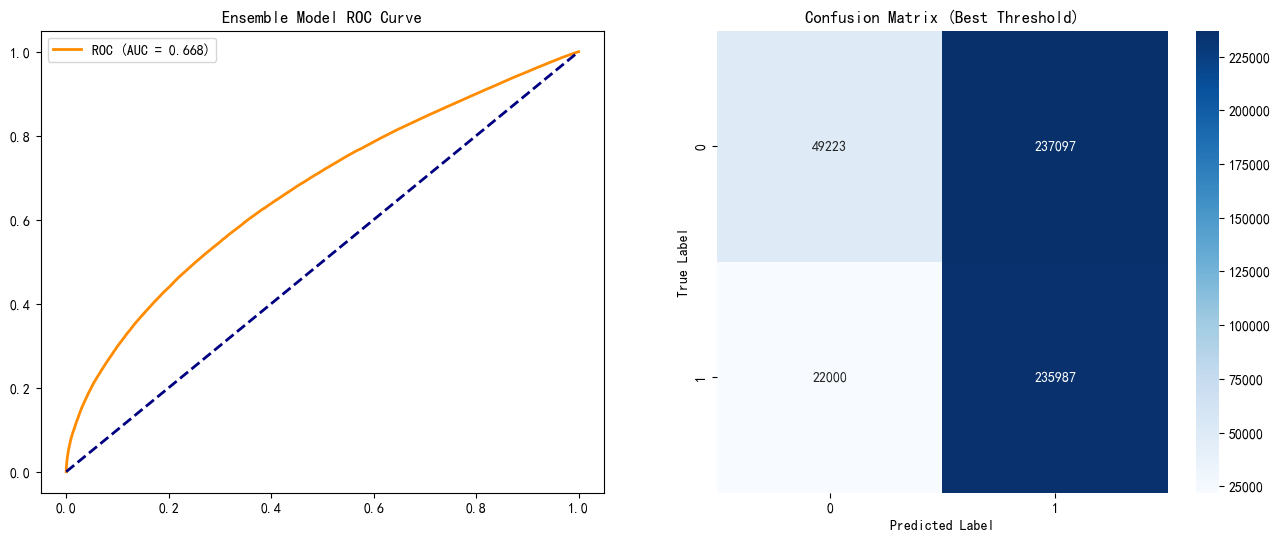

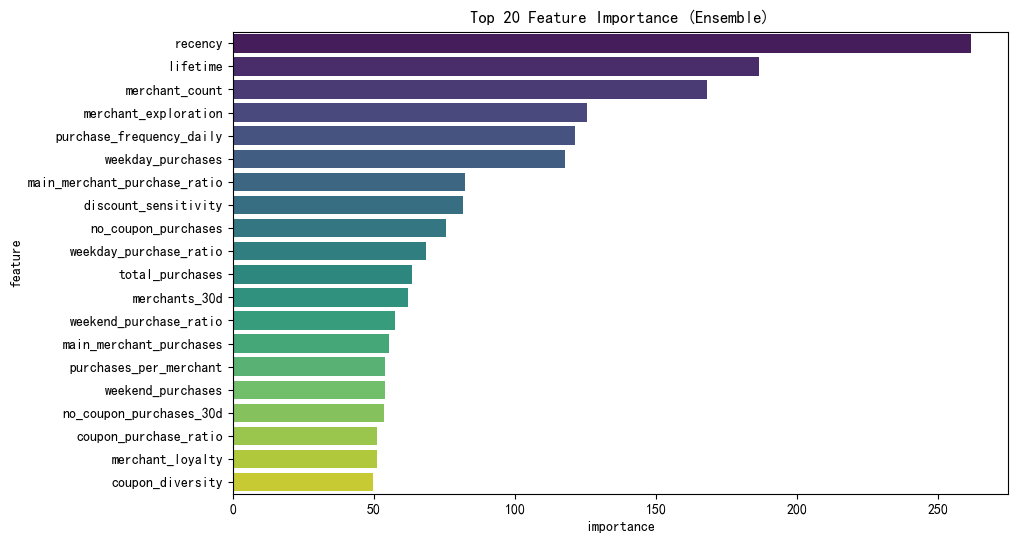

In [8]:
# 可视化评估
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_prob_ensemble)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {ensemble_auc:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('Ensemble Model ROC Curve')
ax[0].legend()

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix (Best Threshold)')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
plt.show()

# 特征重要性（Top 20）
plt.figure(figsize=(10, 6))
# 计算融合模型的特征重要性（简单平均两模型的重要性）
feature_importance = (xgb_model.feature_importances_ * 0.4) + (lgb_model.feature_importances_ * 0.6)
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False).head(20)
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 20 Feature Importance (Ensemble)')
plt.show()

#### 模型2：促销期模型

In [9]:
# 合并4月和5月数据作为训练集
train_data_promo = pd.concat([data_month4, data_month5], ignore_index=True)

X_train_promo = train_data_promo[feature_cols]
y_train_promo = train_data_promo['label']

# 分割训练验证集
X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(
    X_train_promo, y_train_promo,
    test_size=0.2,
    random_state=42,
    stratify=y_train_promo
)

# 6月数据作为测试集
X_test_p = data_month6[feature_cols]
y_test_p = data_month6['label']

print(f"训练集: {X_train_p.shape}, 正样本率: {y_train_p.mean()*100:.2f}%")
print(f"验证集: {X_val_p.shape}, 正样本率: {y_val_p.mean()*100:.2f}%")
print(f"测试集(6月618): {X_test_p.shape}, 正样本率: {y_test_p.mean()*100:.2f}%")

训练集: (870891, 71), 正样本率: 47.70%
验证集: (217723, 71), 正样本率: 47.70%
测试集(6月618): (544307, 71), 正样本率: 47.29%


##### 训练XGBoost模型

In [11]:
# 训练XGBoost
print("\n训练XGBoost(促销期)...")
xgb_model_promo = xgb.XGBClassifier(**xgb_params)
xgb_model_promo.fit(
    X_train_p, y_train_p,
    eval_set=[(X_val_p, y_val_p)],
    verbose=False
)


训练XGBoost(促销期)...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

##### 训练LightGBM模型

In [12]:
# 训练LightGBM
print("训练LightGBM(促销期)...")
lgb_model_promo = lgb.LGBMClassifier(**lgb_params)
lgb_model_promo.fit(
    X_train_p, y_train_p,
    eval_set=[(X_val_p, y_val_p)],
    callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)]
)

训练LightGBM（促销期）...
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[152]	valid_0's auc: 0.685103


LGBMClassifier(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
               learning_rate=0.05, max_depth=6, metric='auc', n_estimators=500,
               n_jobs=-1, objective='binary', random_state=42, verbosity=-1)

##### 模型融合

In [13]:
# 预测和融合
y_pred_xgb_p = xgb_model_promo.predict_proba(X_test_p)[:, 1]
y_pred_lgb_p = lgb_model_promo.predict_proba(X_test_p)[:, 1]
y_pred_ensemble_p = (y_pred_xgb_p + y_pred_lgb_p) / 2

##### 可视化评估

In [14]:
# 评估
print(f"\n6月(618)测试集性能:")
print(f"  XGBoost AUC: {roc_auc_score(y_test_p, y_pred_xgb_p):.4f}")
print(f"  LightGBM AUC: {roc_auc_score(y_test_p, y_pred_lgb_p):.4f}")
print(f"  Ensemble AUC: {roc_auc_score(y_test_p, y_pred_ensemble_p):.4f}")


6月(618)测试集性能:
  XGBoost AUC: 0.6453
  LightGBM AUC: 0.6447
  Ensemble AUC: 0.6451


#### 平销期与促销期对比

In [15]:
comparison = pd.DataFrame({
    '数据集': ['5月(平销期)', '6月(618促销期)'],
    'XGBoost AUC': [
        roc_auc_score(y_test, y_pred_test),
        roc_auc_score(y_test_p, y_pred_xgb_p)
    ],
    'LightGBM AUC': [
        roc_auc_score(y_test, y_pred_test_lgb),
        roc_auc_score(y_test_p, y_pred_lgb_p)
    ],
    'Ensemble AUC': [
        ensemble_auc,
        roc_auc_score(y_test_p, y_pred_ensemble_p)
    ],
    '正样本率': [
        y_test.mean() * 100,
        y_test_p.mean() * 100
    ]
})

print(comparison.to_string(index=False))

       数据集  XGBoost AUC  LightGBM AUC  Ensemble AUC      正样本率
   5月(平销期)     0.623485      0.623221      0.667583 47.397333
6月(618促销期)     0.645307      0.644744      0.645085 47.288938


#### 模型保存

In [17]:
# 创建模型目录
import os
os.makedirs('../ml_models/regular_period', exist_ok=True)
os.makedirs('../ml_models/promotion_period', exist_ok=True)

# 保存平销期模型
with open('../ml_models/regular_period/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../ml_models/regular_period/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)

# 保存促销期模型
with open('../ml_models/promotion_period/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model_promo, f)

with open('../ml_models/promotion_period/lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_model_promo, f)

# 保存模型元数据
metadata = {
    'regular_period': {
        'train_date': '2016-01-01 to 2016-03-31',
        'test_month': 5,
        'xgb_auc': roc_auc_score(y_test, y_pred_test),
        'lgb_auc': roc_auc_score(y_test, y_pred_test_lgb),
        'ensemble_auc': ensemble_auc,
        'best_threshold': best_threshold,
        'feature_count': len(feature_cols)
    },
    'promotion_period': {
        'train_date': '2016-01-01 to 2016-05-31',
        'test_month': 6,
        'xgb_auc': roc_auc_score(y_test_p, y_pred_xgb_p),
        'lgb_auc': roc_auc_score(y_test_p, y_pred_lgb_p),
        'ensemble_auc': roc_auc_score(y_test_p, y_pred_ensemble_p),
        'feature_count': len(feature_cols)
    }
}

with open('../ml_models/model_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("平销期模型已保存: ml_models/regular_period/")
print("促销期模型已保存: ml_models/promotion_period/")
print("模型元数据已保存: ml_models/model_metadata.pkl")

平销期模型已保存: ml_models/regular_period/
促销期模型已保存: ml_models/promotion_period/
模型元数据已保存: ml_models/model_metadata.pkl
